# Two-color statistics with CellposeSAM

In [27]:
# Uncomment to install missing packages if needed
# !pip install scikit-image tifffile cellpose pandas seaborn scipy numpy matplotlib

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import scipy.stats
import tifffile
import warnings
import torch
from cellpose import models
from skimage.filters import threshold_otsu
from skimage.segmentation import find_boundaries
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')

### Parameters

In [29]:
# --- Input files ---
left_path  = "/Volumes/gmgaoSSD/DEFAULT_USER/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/Dox24h/TXSHA-Dox24h-SPEN_JF549_H3K27ac_DL650-SACD-FOV-9-SACD-left.tif"
right_path = "/Volumes/gmgaoSSD/DEFAULT_USER/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/Dox24h/TXSHA-Dox24h-SPEN_JF549_H3K27ac_DL650-SACD-FOV-9-SACD-right.tif"

# --- Classification thresholds ---
use_manual_threshold     = True   # False => use per-cell Otsu
manual_threshold         = 0.3    # pixels in left image above this are 'cloud'
cloud_pixel_num_threshold = 200   # min cloud pixels to classify cell as 'with_cloud'

# --- Manders' threshold (pixels below this are treated as 'no signal') ---
# Set to 0 to use any positive pixel, or a small positive value to reduce noise
mcc_threshold_L = 0.13   # threshold for left channel in MCC computation
mcc_threshold_R = 0.05   # threshold for right channel in MCC computation

# --- CSV output ---
save_csv    = True
csv_out_path = left_path[:-8] + "TwoColorStats_CellposeSAM_results.csv"

# --- Intensity display scaling (percentile) ---
display_pct_lo, display_pct_hi = 1, 99   # for contrast stretching in visualisations

### Load Images

In [30]:
img_L_orig = tifffile.imread(left_path).astype(np.float32)
img_R_orig = tifffile.imread(right_path).astype(np.float32)

# Multiply by 100 to bring small values into a suitable range for CellposeSAM
img_L = img_L_orig * 100.0
img_R = img_R_orig * 100.0

print("Image shapes:", img_L.shape, img_R.shape)
print(f"Left  range: [{img_L_orig.min():.4f}, {img_L_orig.max():.4f}]")
print(f"Right range: [{img_R_orig.min():.4f}, {img_R_orig.max():.4f}]")

Image shapes: (1368, 856) (1368, 856)
Left  range: [0.0008, 1.3939]
Right range: [-0.0000, 1.6598]


### Run Cellpose on Right Image

In [31]:
# Auto-detect GPU (CUDA or Apple MPS)
use_gpu = torch.cuda.is_available() or torch.backends.mps.is_available()
print(f"Using GPU: {use_gpu}")

model = models.CellposeModel(gpu=use_gpu)
masks, flows, styles = model.eval(img_R+img_L, diameter=200)

num_cells = len(np.unique(masks)) - 1
print(f"Detected {num_cells} nuclei.")

Using GPU: True


Resizing is deprecated in v4.0.1+


Detected 7 nuclei.


### Visual Inspection 1 — Nucleus Segmentation Overlay

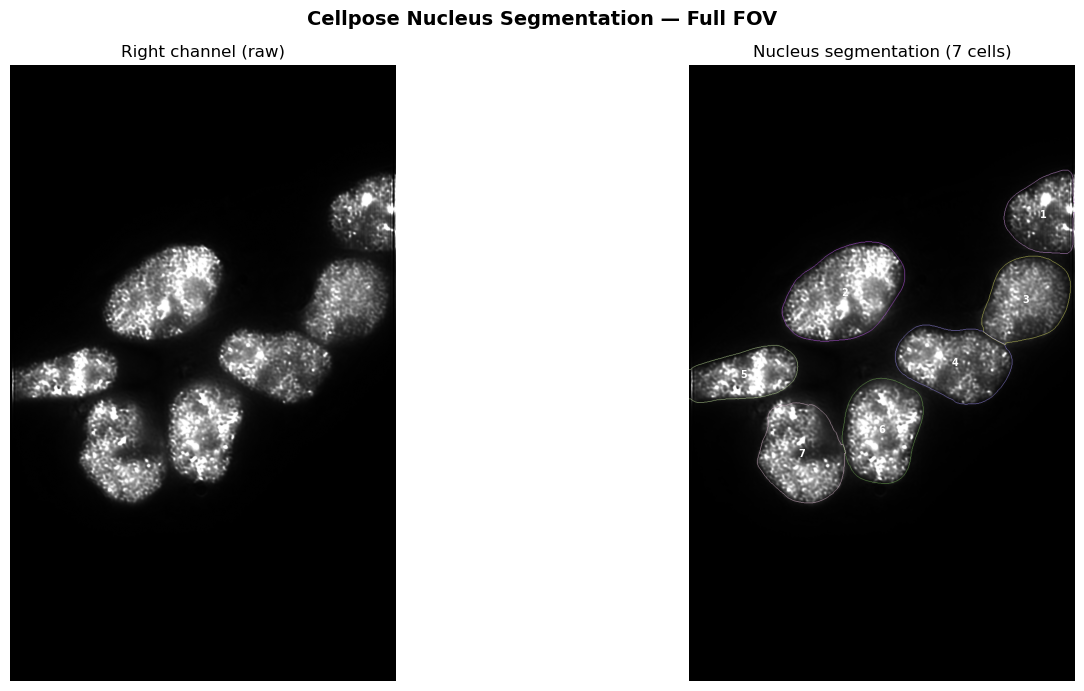

In [32]:
def norm_img(img, plo=1, phi=99):
    """Percentile contrast stretch to [0,1]."""
    lo, hi = np.percentile(img, plo), np.percentile(img, phi)
    return np.clip((img - lo) / (hi - lo + 1e-9), 0, 1)

# Build a colour-coded nucleus overlay on the right channel
rng = np.random.default_rng(42)
cell_ids = np.unique(masks)[1:]   # skip background (0)
colours = rng.uniform(0.3, 1.0, size=(len(cell_ids), 3))  # random bright colours per cell
colour_map = {cid: col for cid, col in zip(cell_ids, colours)}

overlay = np.stack([norm_img(img_R, display_pct_lo, display_pct_hi)] * 3, axis=-1)
for cid, col in colour_map.items():
    boundary = find_boundaries(masks == cid, mode='outer')
    overlay[boundary] = col

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(norm_img(img_R, display_pct_lo, display_pct_hi), cmap='gray')
axes[0].set_title('Right channel (raw)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f'Nucleus segmentation ({num_cells} cells)', fontsize=12)
for cid in cell_ids:
    ys, xs = np.where(masks == cid)
    cy, cx = ys.mean(), xs.mean()
    axes[1].text(cx, cy, str(cid), color='white', fontsize=7,
                 ha='center', va='center', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Cellpose Nucleus Segmentation — Full FOV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Helper Functions

In [33]:
def compute_pcc(arr1, arr2):
    """Pearson Correlation Coefficient between two 1-D arrays. Returns (r, p) or (nan, nan)."""
    try:
        r, p = scipy.stats.pearsonr(arr1, arr2)
        return float(r), float(p)
    except Exception:
        return np.nan, np.nan


def compute_mcc(L_vals, R_vals, thr_L=0.0, thr_R=0.0):
    """
    Manders' Colocalization Coefficients.
        M1 = sum(L where R > thr_R) / sum(L)   — fraction of L signal colocalising with R
        M2 = sum(R where L > thr_L) / sum(R)   — fraction of R signal colocalising with L
    Returns (M1, M2). Returns nan for a channel whose total intensity is 0.
    """
    sum_L = np.sum(L_vals)
    sum_R = np.sum(R_vals)
    M1 = float(np.sum(L_vals[R_vals > thr_R]) / sum_L) if sum_L > 0 else np.nan
    M2 = float(np.sum(R_vals[L_vals > thr_L]) / sum_R) if sum_R > 0 else np.nan
    return M1, M2

### Classify Cells and Calculate PCC + MCC

In [34]:
cells_with_cloud = []
cells_no_cloud   = []
cloud_masks_dict = {}   # cell_id -> boolean mask for cloud region (for visualisation)

for cell_id in np.unique(masks):
    if cell_id == 0:
        continue

    mask_c = masks == cell_id
    L_vals = img_L_orig[mask_c]
    R_vals = img_R_orig[mask_c]

    # --- Cloud threshold ---
    if use_manual_threshold:
        thresh = manual_threshold
    else:
        try:
            thresh = threshold_otsu(L_vals)
        except Exception:
            thresh = manual_threshold

    pixels_above_thresh = np.sum(L_vals > thresh)
    is_with_cloud = pixels_above_thresh > cloud_pixel_num_threshold

    # --- Whole-cell PCC ---
    pcc_whole, pval_whole = compute_pcc(L_vals, R_vals)

    # --- Whole-cell MCC ---
    mcc_M1_whole, mcc_M2_whole = compute_mcc(L_vals, R_vals,
                                              thr_L=mcc_threshold_L,
                                              thr_R=mcc_threshold_R)

    if is_with_cloud:
        cloud_mask     = (img_L_orig > thresh) & mask_c
        non_cloud_mask = mask_c & (~cloud_mask)
        cloud_masks_dict[cell_id] = cloud_mask

        L_bg = img_L_orig[non_cloud_mask]
        R_bg = img_R_orig[non_cloud_mask]

        # Background PCC (outside cloud)
        if len(L_bg) > 2:
            pcc_bg, pval_bg = compute_pcc(L_bg, R_bg)
        else:
            pcc_bg, pval_bg = np.nan, np.nan

        # Background MCC (outside cloud)
        if len(L_bg) > 0:
            mcc_M1_bg, mcc_M2_bg = compute_mcc(L_bg, R_bg,
                                                thr_L=mcc_threshold_L,
                                                thr_R=mcc_threshold_R)
        else:
            mcc_M1_bg, mcc_M2_bg = np.nan, np.nan

        cells_with_cloud.append({
            'cell_id': cell_id, 'type': 'with_cloud',
            'size': len(L_vals), 'peak_size': int(pixels_above_thresh),
            'threshold_used': thresh,
            # PCC
            'pcc_whole': pcc_whole, 'pval_whole': pval_whole,
            'pcc_bg':    pcc_bg,    'pval_bg':    pval_bg,
            # MCC
            'mcc_M1_whole': mcc_M1_whole, 'mcc_M2_whole': mcc_M2_whole,
            'mcc_M1_bg':    mcc_M1_bg,    'mcc_M2_bg':    mcc_M2_bg,
        })
    else:
        cells_no_cloud.append({
            'cell_id': cell_id, 'type': 'no_cloud',
            'size': len(L_vals), 'peak_size': int(pixels_above_thresh),
            'threshold_used': thresh,
            # PCC
            'pcc_whole': pcc_whole, 'pval_whole': pval_whole,
            'pcc_bg':    np.nan,    'pval_bg':    np.nan,
            # MCC
            'mcc_M1_whole': mcc_M1_whole, 'mcc_M2_whole': mcc_M2_whole,
            'mcc_M1_bg':    np.nan,       'mcc_M2_bg':    np.nan,
        })

print(f"with_cloud cells: {len(cells_with_cloud)}")
print(f"no_cloud   cells: {len(cells_no_cloud)}")

with_cloud cells: 2
no_cloud   cells: 5


### Visual Inspection 2 — Cloud Regions in Type 1 (with_cloud) Cells

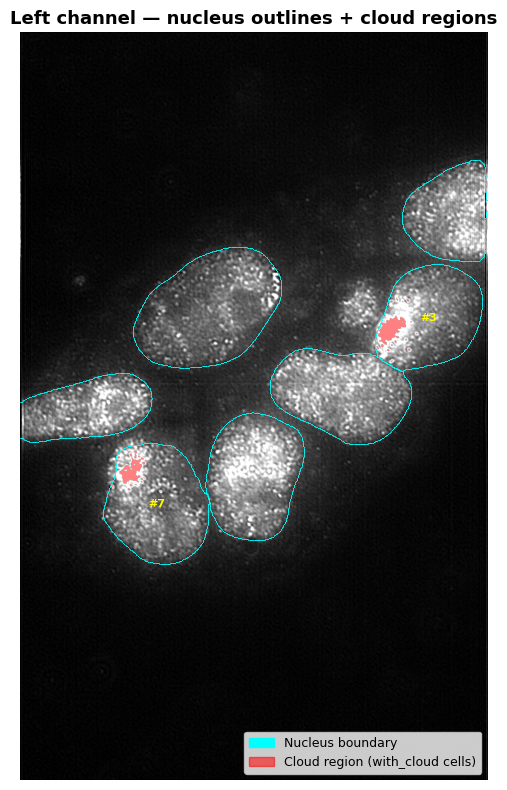

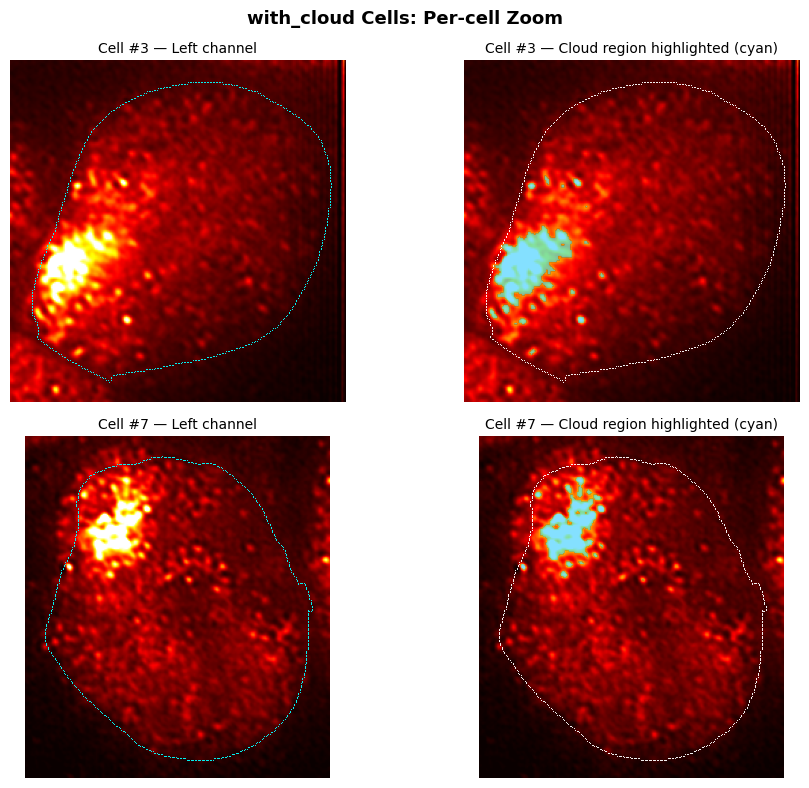

In [35]:
if len(cloud_masks_dict) == 0:
    print("No with_cloud cells detected. Skipping cloud visualisation.")
else:
    # --- Full-FOV overview: left image with cloud regions highlighted in red ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(norm_img(img_L_orig, display_pct_lo, display_pct_hi), cmap='gray')

    # Nucleus outlines
    for cid in cell_ids:
        boundary = find_boundaries(masks == cid, mode='outer')
        yx = np.argwhere(boundary)
        ax.scatter(yx[:, 1], yx[:, 0], s=0.3, c='cyan', linewidths=0)

    # Cloud region overlay (red, semi-transparent)
    combined_cloud = np.zeros(img_L_orig.shape, dtype=bool)
    for cid, cm in cloud_masks_dict.items():
        combined_cloud |= cm
    cloud_rgba = np.zeros((*img_L_orig.shape, 4), dtype=np.float32)
    cloud_rgba[combined_cloud] = [1.0, 0.1, 0.1, 0.55]
    ax.imshow(cloud_rgba)

    # Label with_cloud cells
    for cid in cloud_masks_dict:
        ys, xs = np.where(masks == cid)
        ax.text(xs.mean(), ys.mean(), f"#{cid}", color='yellow', fontsize=8,
                ha='center', va='center', fontweight='bold')

    cyan_patch  = mpatches.Patch(color='cyan',  label='Nucleus boundary')
    red_patch   = mpatches.Patch(color='red',   label='Cloud region (with_cloud cells)', alpha=0.55)
    ax.legend(handles=[cyan_patch, red_patch], loc='lower right', fontsize=9)
    ax.set_title('Left channel — nucleus outlines + cloud regions', fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # --- Per-cell zoom-ins for each with_cloud cell ---
    n_cloud = len(cloud_masks_dict)
    fig, axes = plt.subplots(n_cloud, 2, figsize=(10, 4 * n_cloud))
    if n_cloud == 1:
        axes = axes[np.newaxis, :]   # keep 2-D indexing consistent

    for row_idx, (cid, cm) in enumerate(cloud_masks_dict.items()):
        ys, xs = np.where(masks == cid)
        pad = 15
        y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, img_L_orig.shape[0])
        x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, img_L_orig.shape[1])

        crop_L    = img_L_orig[y0:y1, x0:x1]
        crop_mask = masks[y0:y1, x0:x1] == cid
        crop_cloud = cm[y0:y1, x0:x1]

        # Left channel
        ax = axes[row_idx, 0]
        ax.imshow(norm_img(crop_L, display_pct_lo, display_pct_hi), cmap='hot')
        nb = find_boundaries(crop_mask, mode='outer')
        yx_nb = np.argwhere(nb)
        ax.scatter(yx_nb[:, 1], yx_nb[:, 0], s=0.5, c='cyan', linewidths=0)
        ax.set_title(f'Cell #{cid} — Left channel', fontsize=10)
        ax.axis('off')

        # Left channel + cloud mask
        ax = axes[row_idx, 1]
        ax.imshow(norm_img(crop_L, display_pct_lo, display_pct_hi), cmap='hot')
        cloud_rgba_crop = np.zeros((*crop_L.shape, 4), dtype=np.float32)
        cloud_rgba_crop[crop_cloud] = [0.2, 0.8, 1.0, 0.6]
        ax.imshow(cloud_rgba_crop)
        nb_full = find_boundaries(crop_mask, mode='outer')
        yx_nb2  = np.argwhere(nb_full)
        ax.scatter(yx_nb2[:, 1], yx_nb2[:, 0], s=0.5, c='white', linewidths=0)
        ax.set_title(f'Cell #{cid} — Cloud region highlighted (cyan)', fontsize=10)
        ax.axis('off')

    plt.suptitle('with_cloud Cells: Per-cell Zoom', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Results Summary Table

In [36]:
df_all = pd.DataFrame(cells_with_cloud + cells_no_cloud).sort_values('cell_id').reset_index(drop=True)

# Reorder columns for readability
col_order = [
    'cell_id', 'type', 'size', 'peak_size', 'threshold_used',
    'pcc_whole', 'pval_whole', 'pcc_bg', 'pval_bg',
    'mcc_M1_whole', 'mcc_M2_whole', 'mcc_M1_bg', 'mcc_M2_bg',
]
df_all = df_all[col_order]

display(df_all)

,cell_id,type,size,peak_size,threshold_used,pcc_whole,pval_whole,pcc_bg,pval_bg,mcc_M1_whole,mcc_M2_whole,mcc_M1_bg,mcc_M2_bg
0,1,no_cloud,21768,75,0.3,0.387545,0.000000e+00,NaN,NaN,0.069020,0.692449,NaN,NaN
1,2,no_cloud,42732,78,0.3,0.303703,0.000000e+00,NaN,NaN,0.182487,0.149747,NaN,NaN
2,3,with_cloud,28533,1607,0.3,0.195670,3.311003e-244,0.496688,0.0,0.017892,0.514231,0.018816,0.485538
3,4,no_cloud,32853,50,0.3,0.447258,0.000000e+00,NaN,NaN,0.050377,0.645283,NaN,NaN
4,5,no_cloud,22139,83,0.3,0.288477,0.000000e+00,NaN,NaN,0.195226,0.618469,NaN,NaN
5,6,no_cloud,32317,150,0.3,0.338546,0.000000e+00,NaN,NaN,0.200389,0.697046,NaN,NaN
6,7,with_cloud,32359,1267,0.3,0.092000,9.087651e-62,0.244093,0.0,0.084353,0.436880,0.089817,0.414318


### Save CSV

In [37]:
if save_csv:
    df_all.to_csv(csv_out_path, index=False)
    print(f"Results saved to: {csv_out_path}")
else:
    print("CSV saving skipped (save_csv = False).")

Results saved to: /Volumes/gmgaoSSD/DEFAULT_USER/20260413_ONI-gmgao-SPEN_H3K27ac_dSTORM_SACD/Dox24h/TXSHA-Dox24h-SPEN_JF549_H3K27ac_DL650-SACD-FOV-9-SACD-TwoColorStats_CellposeSAM_results.csv


### Plot PCC Statistics

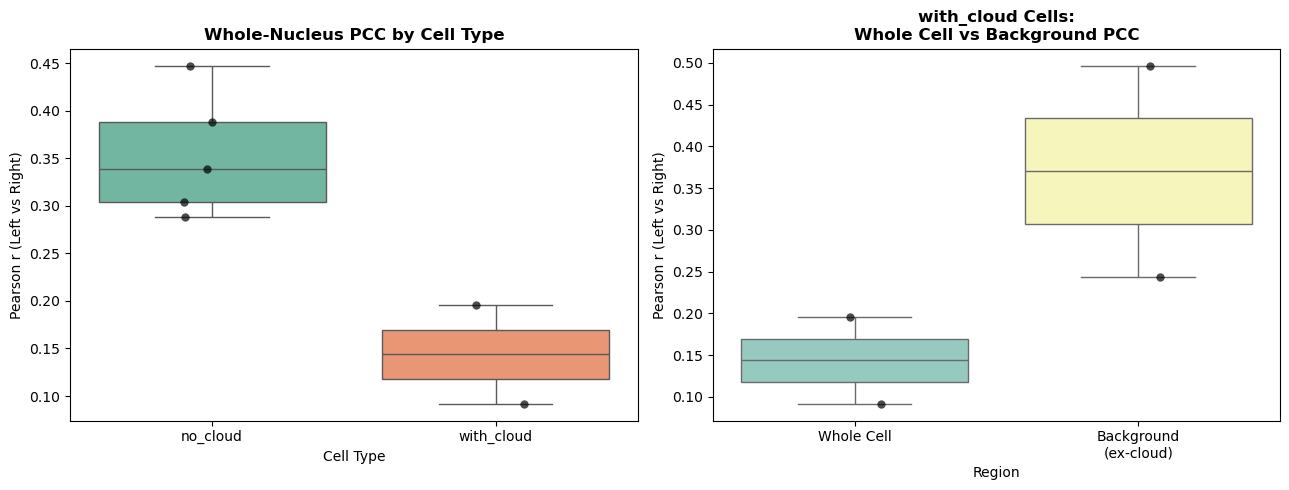

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Whole-nucleus PCC grouped by cell type ---
ax = axes[0]
sns.boxplot(data=df_all, x='type', y='pcc_whole', palette='Set2', ax=ax)
sns.stripplot(data=df_all, x='type', y='pcc_whole', color='black', alpha=0.7,
              jitter=True, size=6, ax=ax)
ax.set_title('Whole-Nucleus PCC by Cell Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson r (Left vs Right)')
ax.set_xlabel('Cell Type')

# --- Plot 2: with_cloud cells — whole vs background PCC ---
ax = axes[1]
df_cloud_only = df_all[df_all['type'] == 'with_cloud']
if len(df_cloud_only) > 0:
    df_melt = df_cloud_only.melt(
        id_vars=['cell_id'],
        value_vars=['pcc_whole', 'pcc_bg'],
        var_name='Region', value_name='PCC'
    )
    df_melt['Region'] = df_melt['Region'].map({
        'pcc_whole': 'Whole Cell',
        'pcc_bg': 'Background\n(ex-cloud)'
    })
    sns.boxplot(data=df_melt, x='Region', y='PCC', palette='Set3', ax=ax)
    sns.stripplot(data=df_melt, x='Region', y='PCC', color='black',
                  alpha=0.7, jitter=True, size=6, ax=ax)
    ax.set_title('with_cloud Cells:\nWhole Cell vs Background PCC', fontsize=12, fontweight='bold')
    ax.set_ylabel('Pearson r (Left vs Right)')
    ax.set_xlabel('Region')
else:
    ax.text(0.5, 0.5, 'No with_cloud cells', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('with_cloud Cells: Whole vs Background PCC')

plt.tight_layout()
plt.show()

### Plot MCC Statistics

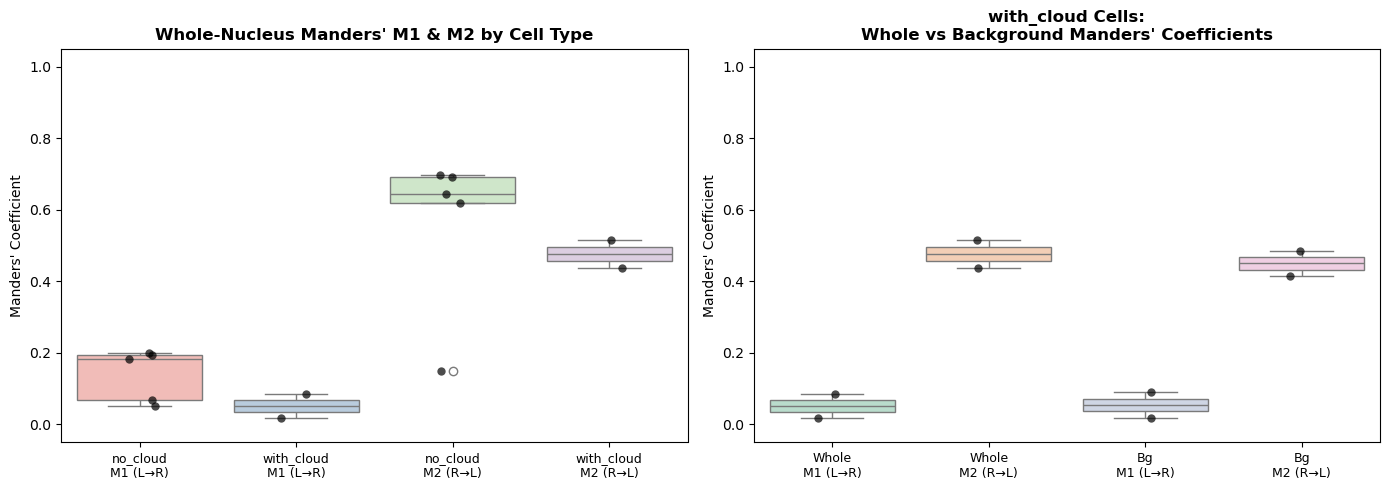

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Whole-nucleus M1 and M2 grouped by cell type ---
ax = axes[0]
df_mcc_all = df_all.melt(
    id_vars=['cell_id', 'type'],
    value_vars=['mcc_M1_whole', 'mcc_M2_whole'],
    var_name='Coefficient', value_name='Value'
)
df_mcc_all['Label'] = df_mcc_all['type'] + '\n' + df_mcc_all['Coefficient'].map({
    'mcc_M1_whole': 'M1 (L→R)',
    'mcc_M2_whole': 'M2 (R→L)'
})
sns.boxplot(data=df_mcc_all, x='Label', y='Value', palette='Pastel1', ax=ax)
sns.stripplot(data=df_mcc_all, x='Label', y='Value', color='black',
              alpha=0.7, jitter=True, size=6, ax=ax)
ax.set_title("Whole-Nucleus Manders' M1 & M2 by Cell Type", fontsize=12, fontweight='bold')
ax.set_ylabel("Manders' Coefficient")
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=9)
ax.set_ylim(-0.05, 1.05)

# --- Plot 2: with_cloud cells — whole vs background M1 and M2 ---
ax = axes[1]
if len(df_cloud_only) > 0:
    df_mcc_cloud = df_cloud_only.melt(
        id_vars=['cell_id'],
        value_vars=['mcc_M1_whole', 'mcc_M2_whole', 'mcc_M1_bg', 'mcc_M2_bg'],
        var_name='Coefficient', value_name='Value'
    )
    df_mcc_cloud['Region'] = df_mcc_cloud['Coefficient'].map({
        'mcc_M1_whole': 'Whole\nM1 (L→R)',
        'mcc_M2_whole': 'Whole\nM2 (R→L)',
        'mcc_M1_bg':    'Bg\nM1 (L→R)',
        'mcc_M2_bg':    'Bg\nM2 (R→L)',
    })
    sns.boxplot(data=df_mcc_cloud, x='Region', y='Value', palette='Pastel2', ax=ax)
    sns.stripplot(data=df_mcc_cloud, x='Region', y='Value', color='black',
                  alpha=0.7, jitter=True, size=6, ax=ax)
    ax.set_title("with_cloud Cells:\nWhole vs Background Manders' Coefficients",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("Manders' Coefficient")
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)
    ax.set_ylim(-0.05, 1.05)
else:
    ax.text(0.5, 0.5, 'No with_cloud cells', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("with_cloud Cells: Manders'")

plt.tight_layout()
plt.show()